In [8]:
import sys
import os
from pathlib import Path
    
# Add project root to path\n",
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.io
from PIL import Image
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
    
from src.flowers102.config import Config
from src.flowers102.data.dataset import Flowers102Dataset
from src.flowers102.data.transforms import get_transforms

## 1. Dataset Initialization

First, let's initialize the dataset and download it if needed.

In [3]:
# Initialize configuration
    
config = Config()
print(f"Data directory: {config.data_dir}")

Data directory: /Users/victoroko/Documents/flowers102-classification/data/flowers102


In [4]:
# Initialize the dataset (this will download it if needed)

dataset = Flowers102Dataset(config.data_dir, split='train', download=True)
print(f"Training set size: {len(dataset)}")

val_dataset = Flowers102Dataset(config.data_dir, split='val', download=False)
print(f"Validation set size: {len(val_dataset)}")
    
test_dataset = Flowers102Dataset(config.data_dir, split='test', download=False)
print(f"Test set size: {len(test_dataset)}")

100%|██████████| 14989/14989 [00:00<00:00, 2971097.48it/s]

Training set size: 1020
Validation set size: 1020
Test set size: 6149


## 2. Dataset Exploration
    
Let's explore the dataset characteristics.

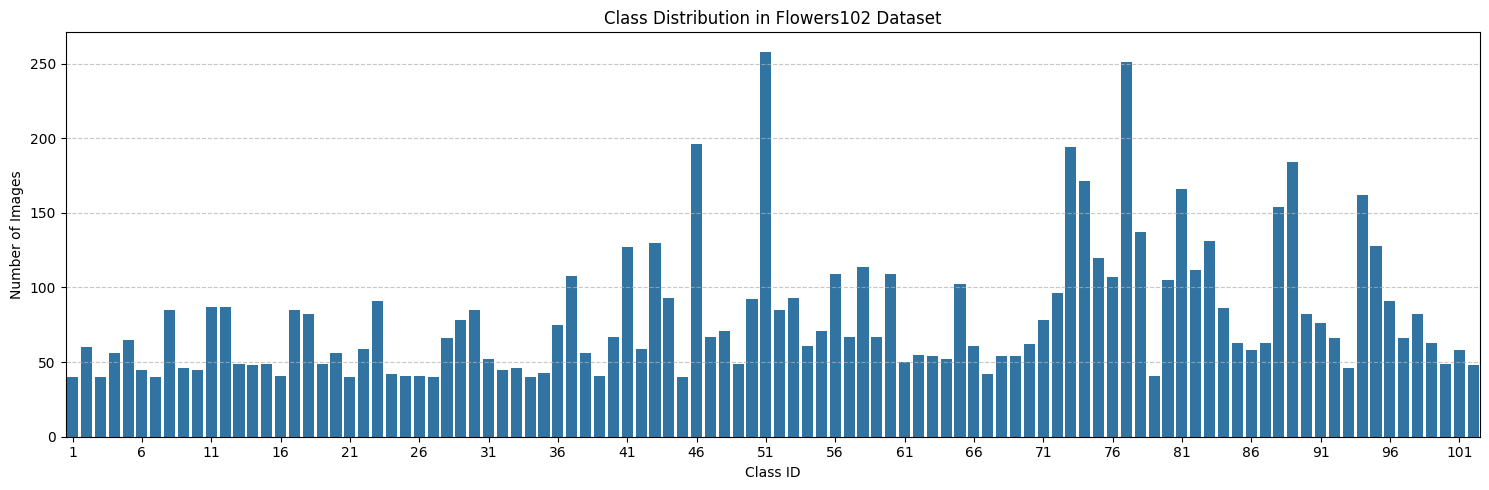

Number of classes: 102
Min images per class: 40
Max images per class: 258
Mean images per class: 80.28
Median images per class: 66.0


In [5]:
# Load the labels to get class distribution

labels_data = scipy.io.loadmat(str(config.data_dir / 'imagelabels.mat'))
labels = labels_data['labels'][0].tolist()
    
# Count instances per class",
class_counts = pd.Series(labels).value_counts().sort_index()
    
# Plot class distribution
plt.figure(figsize=(15, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Flowers102 Dataset')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.xticks(range(0, len(class_counts), 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
    
# Print statistics
print(f"Number of classes: {len(class_counts)}")
print(f"Min images per class: {class_counts.min()}")
print(f"Max images per class: {class_counts.max()}")
print(f"Mean images per class: {class_counts.mean():.2f}")
print(f"Median images per class: {class_counts.median()}")


## 3. Image Visualization
    
Let's visualize some images from the dataset.

In [6]:
def show_images(dataset, indices=None, num_images=5, figsize=(15, 3)):
    "Show images from the dataset."
    if indices is None:
        indices = np.random.choice(len(dataset), num_images, replace=False)
    fig, axes = plt.subplots(1, len(indices), figsize=figsize)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        if isinstance(img, torch.Tensor):
            img = img.numpy().transpose(1, 2, 0)
            # Denormalize if necessary"
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Class {label}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

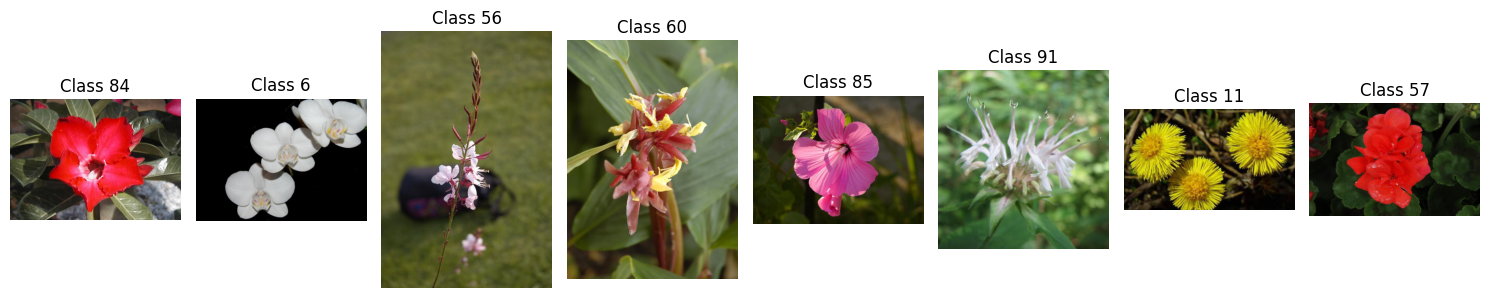

In [9]:
# Visualize random images from the training set
show_images(dataset, num_images=8)

## 4. Image Size Distribution
    
Let's analyze the size distribution of the images.

  0%|          | 0/100 [00:00<?, ?it/s]

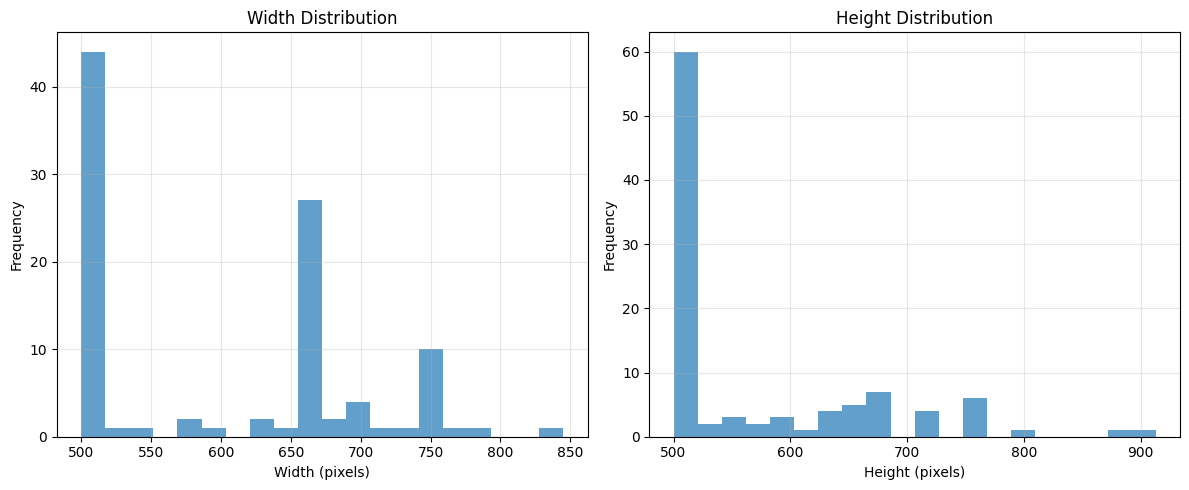

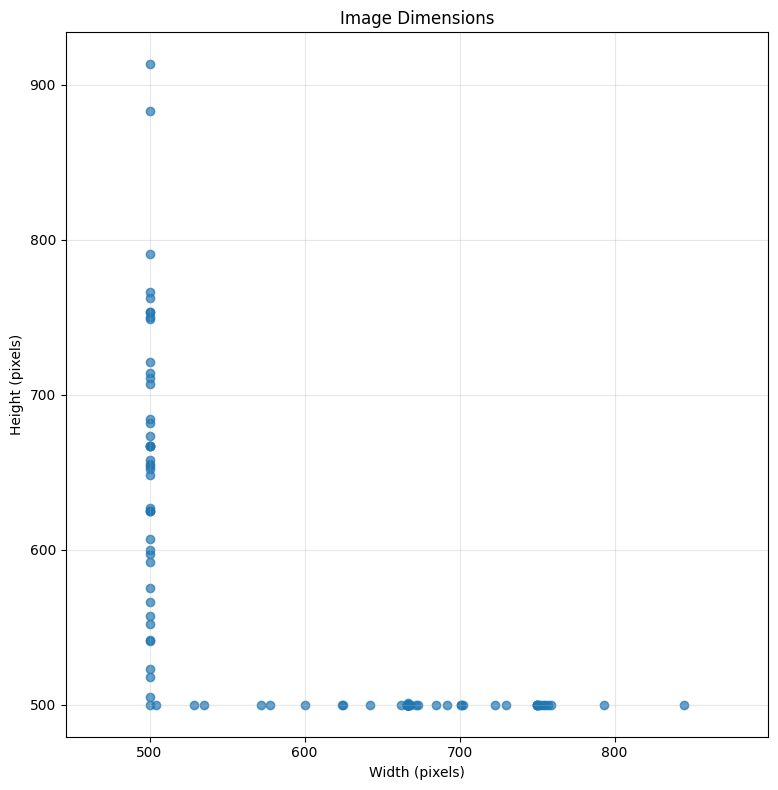

Width - Min: 500, Max: 845, Mean: 602.37
Height - Min: 500, Max: 913, Mean: 567.25


In [10]:
# Collect image sizes

image_sizes = []
for img_path in tqdm(dataset.image_paths[:100]):  # Sample a subset for efficiency
    with Image.open(img_path) as img:
        width, height = img.size
        image_sizes.append((width, height))
    
image_sizes_df = pd.DataFrame(image_sizes, columns=['width', 'height'])

# Plot size distribution
plt.figure(figsize=(12, 5))
    
plt.subplot(1, 2, 1)
plt.hist(image_sizes_df['width'], bins=20, alpha=0.7)
plt.title('Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(image_sizes_df['height'], bins=20, alpha=0.7)
plt.title('Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()
    
# Plot width vs height scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(image_sizes_df['width'], image_sizes_df['height'], alpha=0.7)
plt.title('Image Dimensions')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Width - Min: {image_sizes_df['width'].min()}, Max: {image_sizes_df['width'].max()}, Mean: {image_sizes_df['width'].mean():.2f}")
print(f"Height - Min: {image_sizes_df['height'].min()}, Max: {image_sizes_df['height'].max()}, Mean: {image_sizes_df['height'].mean():.2f}")


## 5. Data Augmentation Visualization

Let's visualize the effect of our data augmentation pipeline.

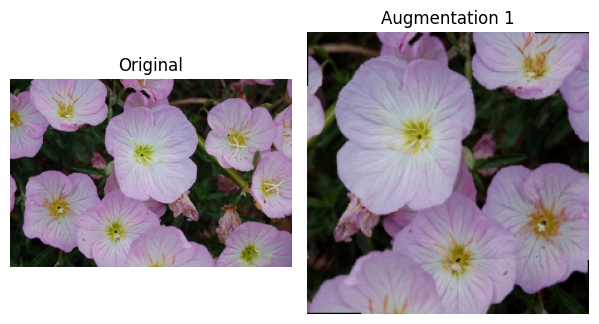

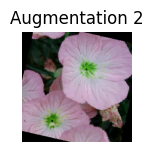

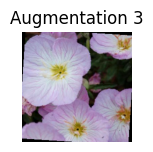

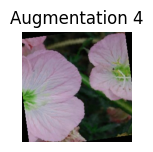

In [11]:
# Get the transformations
transforms = get_transforms()
train_transform = transforms['train']
    
# Select a single image
img_path = dataset.image_paths[0]
original_img = Image.open(img_path).convert('RGB')
    
# Apply the transformation multiple times
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 5, 1)
plt.imshow(original_img)
plt.title('Original')
plt.axis('off')
    
for i in range(4):
    # Apply transformations
    transformed_img = train_transform(original_img)

    # Convert tensor to image
    transformed_img = transformed_img.numpy().transpose(1, 2, 0)
    transformed_img = transformed_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    transformed_img = np.clip(transformed_img, 0, 1)
    
    plt.subplot(1, 5, i+2)
    plt.imshow(transformed_img)
    plt.title(f'Augmentation {i+1}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Split Distribution
    
Let's check the class distribution across train, validation, and test splits.

<Figure size 1500x600 with 0 Axes>

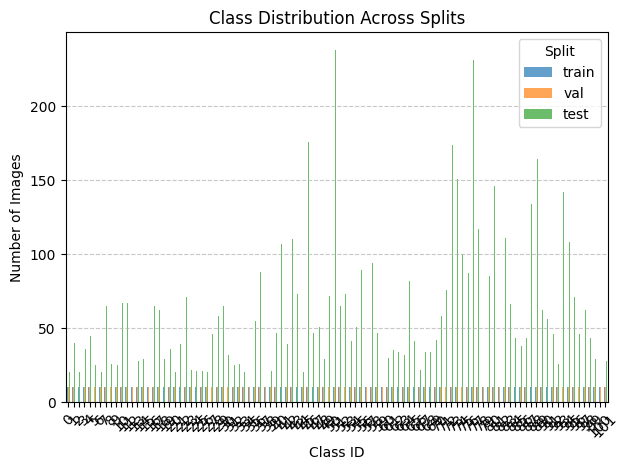

Train split - Min: 10, Max: 10, Mean: 10.00
Val split - Min: 10, Max: 10, Mean: 10.00
Test split - Min: 20, Max: 238, Mean: 60.28


In [12]:
# Get class distribution for each split
train_labels = [label for _, label in dataset]
val_labels = [label for _, label in val_dataset]
test_labels = [label for _, label in test_dataset]
    
train_dist = pd.Series(train_labels).value_counts().sort_index()
val_dist = pd.Series(val_labels).value_counts().sort_index()
test_dist = pd.Series(test_labels).value_counts().sort_index()
    
# Combine into a DataFrame\n",
split_dist = pd.DataFrame({
    'train': train_dist,
    'val': val_dist,
    'test': test_dist
})
    
# Fill NaN with 0
split_dist = split_dist.fillna(0).astype(int)
    
# Plot
plt.figure(figsize=(15, 6))
split_dist.plot(kind='bar', alpha=0.7)
plt.title('Class Distribution Across Splits')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.legend(title='Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Train split - Min: {split_dist['train'].min()}, Max: {split_dist['train'].max()}, Mean: {split_dist['train'].mean():.2f}")
print(f"Val split - Min: {split_dist['val'].min()}, Max: {split_dist['val'].max()}, Mean: {split_dist['val'].mean():.2f}")
print(f"Test split - Min: {split_dist['test'].min()}, Max: {split_dist['test'].max()}, Mean: {split_dist['test'].mean():.2f}")
  

## 7. Conclusion
    
Based on our exploration, we can draw the following conclusions about the Flowers102 dataset:
    
1. The dataset contains 102 classes with varying numbers of images per class.

2. Images have different sizes, which will be standardized by our preprocessing pipeline.

3. Our data augmentation pipeline creates diverse variations of the training images.

4. The train/val/test splits appear to be stratified, maintaining a similar class distribution.
    
These insights will help us design an effective training strategy for the ResNet50 model.